In [ ]:
import numpy as np
from scipy import sparse as sp
from matplotlib import pyplot as plt

"""
Navier-Stokes Lid-Driven Cavity Solver

Author: Claire R. A. Curry
Date: April 22, 2026
Course: APMA 922, Simon Fraser University, 2026

Numerical Methods:
- Finite difference method
- Pressure-velocity coupling performed by Chorin's (1968) projection method
- Time discretization: IMEX Forward Euler convection / Backwards Euler diffusion
- Linear solver: Scipy sparse matrix library

Problem Description:
- Governing equations: Incompressible Navier-Stokes equations
- Domain: 2D unit square [ax,bx] x [ay,by]
- Boundary conditions default: 
  * Top wall: u = 1.0, v = 0.0 (lid)
  * Other walls: u = 0.0, v = 0.0 (no-slip)
"""

"\nNavier-Stokes Lid-Driven Cavity Solver\n\nAuthor: Claire R. A. Curry\nDate: April 22, 2026\nCourse: APMA 922, Simon Fraser University, 2026\n\nNumerical Methods:\n- Finite difference method\n- Pressure-velocity coupling performed by Chorin's (1968) projection method\n- Time discretization: IMEX Forward / Backwards Euler\n- Linear solver: Scipy sparse matrix library\n\nProblem Description:\n- Governing equations: Incompressible Navier-Stokes equations\n- Domain: 2D unit square [ax,bx] x [ay,by]\n- Boundary conditions: \n  * Top wall: u = 1.0, v = 0.0 (lid)\n  * Other walls: u = 0.0, v = 0.0 (no-slip)\n"

In [32]:
# Helper Functions

def applyDirichletBCs(ZZZ,top,bot,left,right):
    ZZZ[0 , :] = bot
    ZZZ[-1, :] = top
    ZZZ[: , 0] = left
    ZZZ[: ,-1] = right
    return ZZZ

def applyNeumannBCs(ZZZ):

    ZZZ = np.pad(ZZZ,1,constant_values=0)
    
    ZZZ[0 , 1:-1] = ZZZ[ 1   ,1:-1]
    ZZZ[-1, 1:-1] = ZZZ[-2   ,1:-1]
    ZZZ[1:-1 , 0] = ZZZ[ 1:-1, 1]
    ZZZ[1:-1 ,-1] = ZZZ[ 1:-1,-2]
    return ZZZ

# Pressure Poisson Solve Matrix Constructor

def five_p_lap_N0(Nx,Ny,dx,dy):

    A = np.zeros((Nx*Ny,Nx*Ny))

    for jj in range(Ny):

        middle = np.eye(Nx)*(-2/dx**2 - 2/dy**2) + np.diag(np.ones(Nx-1)*1/dx**2,k=-1) + np.diag(np.ones(Nx-1)*1/dx**2,k=1)

        A[jj*Nx:(jj+1)*Nx,jj*Nx:(jj+1)*Nx] = middle

        if jj != Ny-1:

            upper = np.eye(Nx)*(1/dy**2)
            lower = np.eye(Nx)*(1/dy**2)


            A[(jj+1)*Nx:(jj+2)*Nx,(jj  )*Nx:(jj+1)*Nx] = lower
            A[(jj  )*Nx:(jj+1)*Nx,(jj+1)*Nx:(jj+2)*Nx] = upper

    for jj in range(Nx):

        # Left
        A[jj*Nx,jj*Nx+1]       += 1/dx**2    

        # Right
        A[-1-jj*Nx,-1-jj*Nx-1] += 1/dx**2

        # Up
        A[jj,jj+Nx]       += 1/dy**2

        # Down
        A[-1-jj,-1-jj-Nx] += 1/dy**2

    return sp.csr_matrix(A)

# Dirichlet Poisson solve for stream function
def five_p_lap_D0(Nx,Ny,dx,dy):

    A = np.zeros((Nx*Ny,Nx*Ny))

    for jj in range(Ny):

        middle = np.eye(Nx)*(-2/dx**2 - 2/dy**2) + np.diag(np.ones(Nx-1)*1/dx**2,k=-1) + np.diag(np.ones(Nx-1)*1/dx**2,k=1)

        A[jj*Nx:(jj+1)*Nx,jj*Nx:(jj+1)*Nx] = middle

        if jj != Ny-1:

            upper = np.eye(Nx)*(1/dy**2)
            lower = np.eye(Nx)*(1/dy**2)


            A[(jj+1)*Nx:(jj+2)*Nx,(jj  )*Nx:(jj+1)*Nx] = lower
            A[(jj  )*Nx:(jj+1)*Nx,(jj+1)*Nx:(jj+2)*Nx] = upper

    return sp.csr_matrix(A)

def get_psi(x,y,u,v):
    
    Nx = x.shape[1] - 2
    Ny = x.shape[0] - 2

    dx = x[0,1] - x[0,0]
    dy = y[1,0] - y[0,0] 
    vorticity = (v[1:-1, 2:] - v[1:-1, :-2])/(2*dx) - (u[2:, 1:-1] - u[:-2, 1:-1])/(2*dy)

    LD = five_p_lap_D0(Nx,Ny,dx,dy)

    psi = sp.linalg.spsolve(LD,np.reshape(-vorticity,Nx*Ny))
    psi = np.reshape(psi,(Ny,Nx))

    return psi

In [33]:
def solveNS(ax,bx,ay,by,Nx,Ny,T,Re,method):

    # Grid spacings
    dx = (bx-ax)/(Nx+1)
    dy = (by-ay)/(Ny+1)

    dt = 0.5*np.min([dx,dy])
    TT = np.arange(0,T,dt)
    totalSteps = len(TT)

    XX = np.linspace(ax,bx,Nx+2)
    YY = np.linspace(ay,by,Ny+2)

    # Constructing grid
    XXX,YYY = np.meshgrid(XX,YY)

    # Initial conditions
    UUU = np.zeros_like(XXX)
    VVV = np.zeros_like(XXX)

    UUUnew = np.zeros_like(UUU)
    VVVnew = np.zeros_like(VVV)

    UTopBCValue   = 1
    UBotBCValue   = 0
    URightBCValue = 0
    ULeftBCValue  = 0

    VTopBCValue   = 0
    VBotBCValue   = 0
    VRightBCValue = 0
    VLeftBCValue  = 0

    # Non-ADI Boundary Conditions
    UTopBC   = np.ones(Nx+2)    *(UTopBCValue)
    UBotBC   = np.ones(Nx+2)    *(UBotBCValue)
    URightBC = np.ones((1,Ny+2))*(URightBCValue)
    ULeftBC  = np.ones((1,Ny+2))*(ULeftBCValue)

    VTopBC   = np.ones(Nx+2)    *(VTopBCValue)
    VBotBC   = np.ones(Nx+2)    *(VBotBCValue)
    VRightBC = np.ones((1,Ny+2))*(VRightBCValue)
    VLeftBC  = np.ones((1,Ny+2))*(VLeftBCValue)

    # Apply boundary conditions to the solution matrices for use in explicit differencing
    UUU = applyDirichletBCs(UUU,UTopBC,UBotBC,ULeftBC,URightBC)
    VVV = applyDirichletBCs(VVV,VTopBC,VBotBC,VLeftBC,VRightBC)

    # Explicit Finite Difference Stencils
    INT = np.zeros_like(UUU, dtype=bool)
    INT[1:-1, 1:-1] = True # Interior points

    IP1 = np.zeros_like(UUU, dtype=bool)
    IP1[1:-1, 2:] = True # i+1

    IM1 = np.zeros_like(UUU, dtype=bool)
    IM1[1:-1, :-2] = True # i-1

    JP1 = np.zeros_like(UUU, dtype=bool)
    JP1[2:, 1:-1] = True # j+1

    JM1 = np.zeros_like(UUU, dtype=bool)
    JM1[:-2, 1:-1] = True # j-1

    # Initializing static matrices

    # Diffusion Implicit Matrix
    Dxx = sp.diags([1, -2, 1], [-1, 0, 1], shape=(Nx, Nx), dtype=float) / (dx**2)
    Dyy = sp.diags([1, -2, 1], [-1, 0, 1], shape=(Ny, Ny), dtype=float) / (dy**2)
    L = sp.kron(sp.eye(Ny), Dxx) + sp.kron(Dyy, sp.eye(Nx))
    A = sp.eye(Nx*Ny) - (1/Re) * dt * L
    A = A.tocsr()

    # Poisson Solve
    L = five_p_lap_N0(Nx,Ny,dx,dy).tocsr()

    # Setting up implicit handling of boundary conditions
    impUBounds = np.zeros_like(XXX[1:-1,1:-1])
    impUBounds[-1,:] += dt*UTopBC[1:-1]/(Re*dy**2)
    impUBounds[ 0,:] += dt*UBotBC[1:-1]/(Re*dy**2)
    impUBounds[:,0]  += dt*ULeftBC[0,1:-1]/(Re*dx**2)
    impUBounds[:,-1] += dt*URightBC[0,1:-1]/(Re*dx**2)
    impUBounds = np.reshape(impUBounds,Ny*Nx)

    impVBounds = np.zeros_like(XXX[1:-1,1:-1])
    impVBounds[-1,:] += dt*VTopBC[1:-1]/(Re*dy**2)
    impVBounds[ 0,:] += dt*VBotBC[1:-1]/(Re*dy**2)
    impVBounds[:,0]  += dt*VLeftBC[0,1:-1]/(Re*dx**2)
    impVBounds[:,-1] += dt*VRightBC[0,1:-1]/(Re*dx**2)
    impVBounds = np.reshape(impVBounds,Ny*Nx)

    topEdgeMask = np.zeros_like(XXX[1:-1,1:-1],dtype=bool)
    topEdgeMask[-1,:] = True
    topEdgeMask = np.reshape(topEdgeMask,Ny*Nx)

    # Main time stepping loop
    percent = 0
    for n,t in enumerate(TT):
        
        # Print out percent completion
        if n % (totalSteps//10) == 0:

            print(f"{method} is {percent}% Complete")

            percent += 10

        # Discretization method selection
        match method:
            case "Upwinding": 

                #Upwinding
                rhsU = UUU[INT] - dt*(UUU[INT]*(( UUU[INT] >= 0 )*(UUU[INT] - UUU[IM1])/dx + ( UUU[INT] < 0 )*(UUU[IP1] - UUU[INT])/dx) \
                                +     VVV[INT]*(( VVV[INT] >= 0 )*(UUU[INT] - UUU[JM1])/dy + ( VVV[INT] < 0 )*(UUU[JP1] - UUU[INT])/dy)) \

                rhsV = VVV[INT] - dt*(UUU[INT]*(( UUU[INT] >= 0 )*(VVV[INT] - VVV[IM1])/dx + ( UUU[INT] < 0 )*(VVV[IP1] - VVV[INT])/dx) \
                                +     VVV[INT]*(( VVV[INT] >= 0 )*(VVV[INT] - VVV[JM1])/dy + ( VVV[INT] < 0 )*(VVV[JP1] - VVV[INT])/dy)) \
                                
                UUUnew = sp.linalg.spsolve(A, rhsU + impUBounds)
                VVVnew = sp.linalg.spsolve(A, rhsV + impVBounds)           

            case _: # "Centered"
                
                # Centered in Space              
                rhsU = UUU[INT] - dt*(UUU[INT]*((UUU[IP1] - UUU[IM1])/(2*dx)) \
                                +     VVV[INT]*((UUU[JP1] - UUU[JM1])/(2*dy))) \

                rhsV = VVV[INT] - dt*(UUU[INT]*((VVV[IP1] - VVV[IM1])/(2*dx)) \
                                +     VVV[INT]*((VVV[JP1] - VVV[JM1])/(2*dy))) \
                                
                UUUnew = sp.linalg.spsolve(A, rhsU + impUBounds)
                VVVnew = sp.linalg.spsolve(A, rhsV + impVBounds)


        # Save timestep
        UUU[INT] = UUUnew
        VVV[INT] = VVVnew

        # Chorin's Pressure Correction

        # Calculate divergence
        div = (1/dt)*((UUU[IP1] - UUU[IM1])/(2*dx) + (VVV[JP1] - VVV[JM1])/(2*dy))

        # Poisson Solve
        rhsP = np.reshape(div,Ny*Nx)
        rhsP -= np.mean(rhsP)

        # Pressure correction
        Pc = sp.linalg.spsolve(L,rhsP)
        Pc = np.reshape(Pc,(Ny,Nx)).copy()
        Pc -= np.mean(Pc)
        Pc = applyNeumannBCs(Pc)

        # Velocity corrections
        UUU[INT] = UUU[INT] - dt*(Pc[IP1] - Pc[IM1])/(2*dx)
        VVV[INT] = VVV[INT] - dt*(Pc[JP1] - Pc[JM1])/(2*dy)

    return UUU,VVV,XXX,YYY,T


Centered is 0% Complete
Centered is 10% Complete
Centered is 20% Complete
Centered is 30% Complete
Centered is 40% Complete
Centered is 50% Complete
Centered is 60% Complete
Centered is 70% Complete
Centered is 80% Complete
Centered is 90% Complete
Centered is 100% Complete


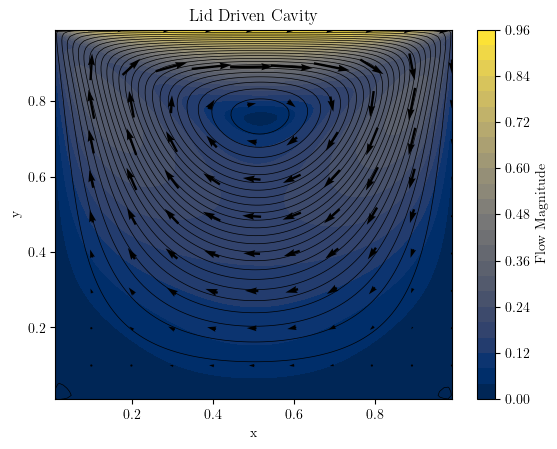

In [40]:
# Example Test Code

Nx = 100
Ny = 100
Re = 10
T = 1

u,v,x,y,t = solveNS(0,1,0,1,Nx,Ny,T,Re,"Centered")

K = np.sqrt(u**2 + v**2)

psi = get_psi(x,y,u,v)

fig,axs = plt.subplots()

arrowCulling = np.min([Nx,Ny])//10
arrowMask = np.zeros_like(u,dtype=bool)
arrowMask[arrowCulling::arrowCulling,arrowCulling::arrowCulling] = True

axs.contour(
    x[1:-1,1:-1],
    y[1:-1,1:-1],
    psi,
    levels=30,
    colors="black",
    linewidths=0.5,
    linestyles="-"
    )

color = axs.contourf(
    x[1:-1,1:-1],
    y[1:-1,1:-1],
    K[1:-1,1:-1],
    levels=30,
    cmap="cividis"
    )

axs.quiver(
    x[arrowMask],
    y[arrowMask],
    u[arrowMask],
    v[arrowMask],
    pivot="middle"
    )

plt.colorbar(color,label="Flow Magnitude")

axs.set(
    xlabel="x",
    ylabel="y",
    title="Lid Driven Cavity",
);
